# Fitting Galaxy Spectra: From Mock to Posterior in Seconds

Spectra contain orders of magnitude more information than photometry. A
200-pixel spectrum constrains ~40× more than 5-band photometry — breaking
degeneracies that plague broadband fitting. This notebook demonstrates
spectroscopic fitting with tengri: parametric and stochastic models,
photometry vs spectroscopy comparison, SNR dependence, and redshift
accessibility.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation import Spectroscopy

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("fitting", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    SPECTRAL_FEATURES,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
FILTER_NAMES = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
obs_joint = Observation(
    photometry=Photometry.from_names(FILTER_NAMES),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)
obs_phot = Observation(photometry=Photometry.from_names(FILTER_NAMES))
obs_spec = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS))

In [3]:
# Parametric model (D = 7)
spec_param = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, observation=obs_joint)
model_param_spec = Model(spec_param, ssp_data, observation=obs_spec)

key = jax.random.PRNGKey(42)
true_param = spec_param.sample(key)
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_param = {**true_param}
true_param["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_param["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_param["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_param["sfh_tsnorm_skew"] = jnp.array(0.3)
true_param["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock_spec = model_param.mock_spectrum(true_param, WAVE_OBS, snr=30.0, key=key)
mock_phot = model_param.mock(true_param, snr=20.0, key=jax.random.fold_in(key, 1))

W0405 02:34:10.264992 36237501 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78382/2049504257.py:15: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, observation=obs_joint)


<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


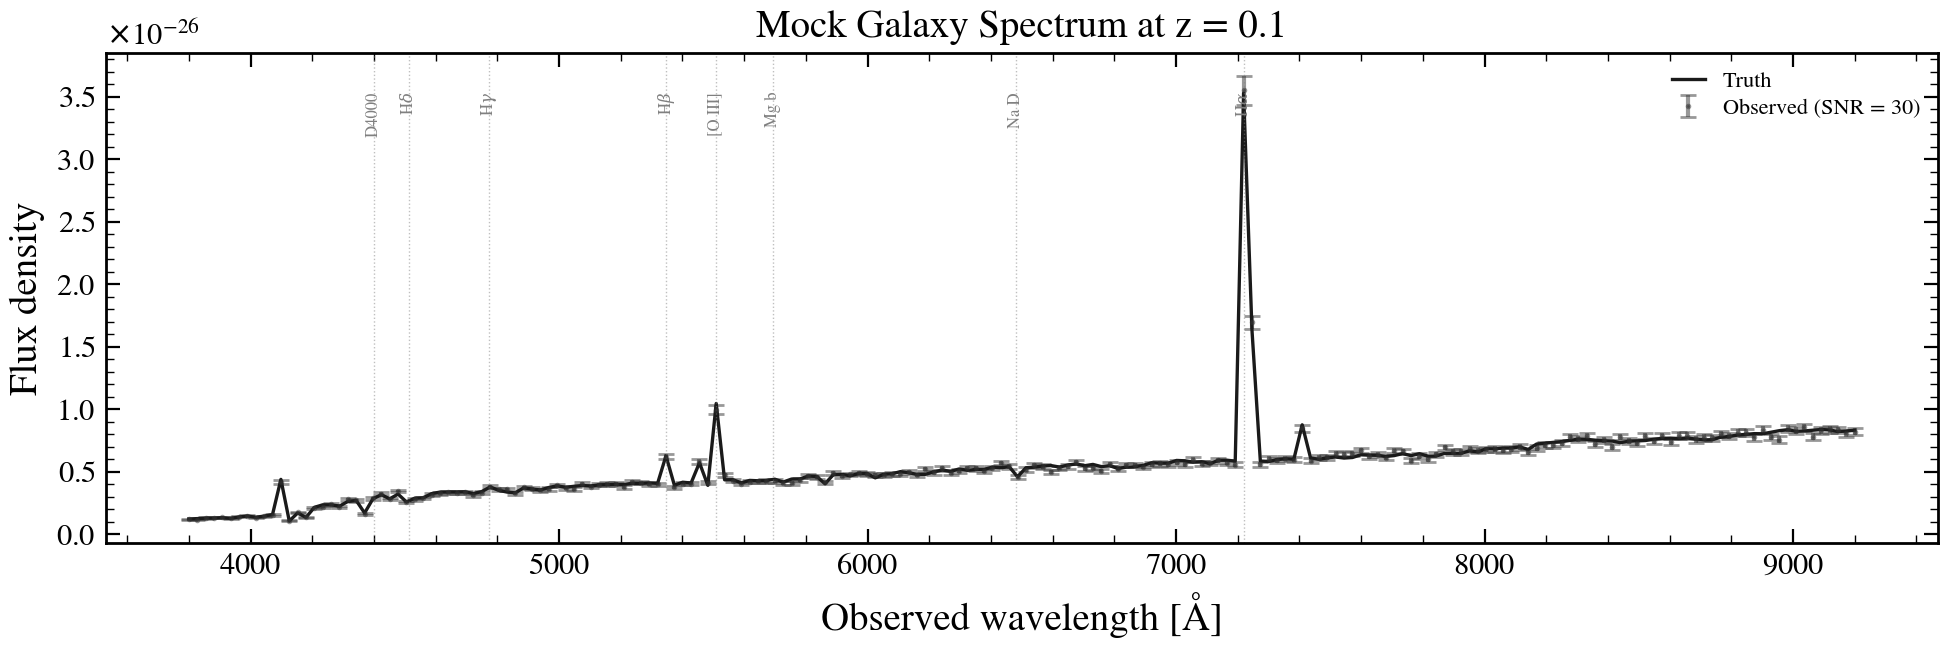

In [4]:
# --- FIGURE 1: Mock spectrum with annotated features ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS),
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.5,
    label="Observed (SNR = 30)",
)
ax.plot(
    np.array(WAVE_OBS), np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1.2, label="Truth"
)

for feat_name, feat_wave in SPECTRAL_FEATURES.items():
    w_obs = feat_wave * 1.1  # z = 0.1
    if 3800 < w_obs < 9200:
        ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
        ax.text(
            w_obs,
            ax.get_ylim()[1] * 0.92,
            feat_name,
            fontsize=6,
            ha="center",
            va="top",
            rotation=90,
            color="grey",
        )

ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.legend(fontsize=8)
ax.set_title("Mock Galaxy Spectrum at z = 0.1")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_mock_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Fit parametric model with native_geovi
fitter_spec = Fitter(model_param_spec, mock_spec.flux_obs, mock_spec.noise)

t0_compile = time.perf_counter()
fitter_spec.compile(verbose=False)
t_compile = time.perf_counter() - t0_compile

result_map = fitter_spec.run("map", n_steps=500, verbose=False)

t0 = time.perf_counter()
result_geovi_spec = fitter_spec.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=5000,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached on disk)")
print(f"native_geovi: {t_run:.1f}s <- runtime per galaxy")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:34:15.990495 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:34:17.721371 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 02:34:27.371053 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:34:39.293352 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 128.1 ± 49.1 (CV=38%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 02:34:48.774424 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


XLA compile: 14.7s (one-time, cached on disk)
native_geovi: 57.5s <- runtime per galaxy


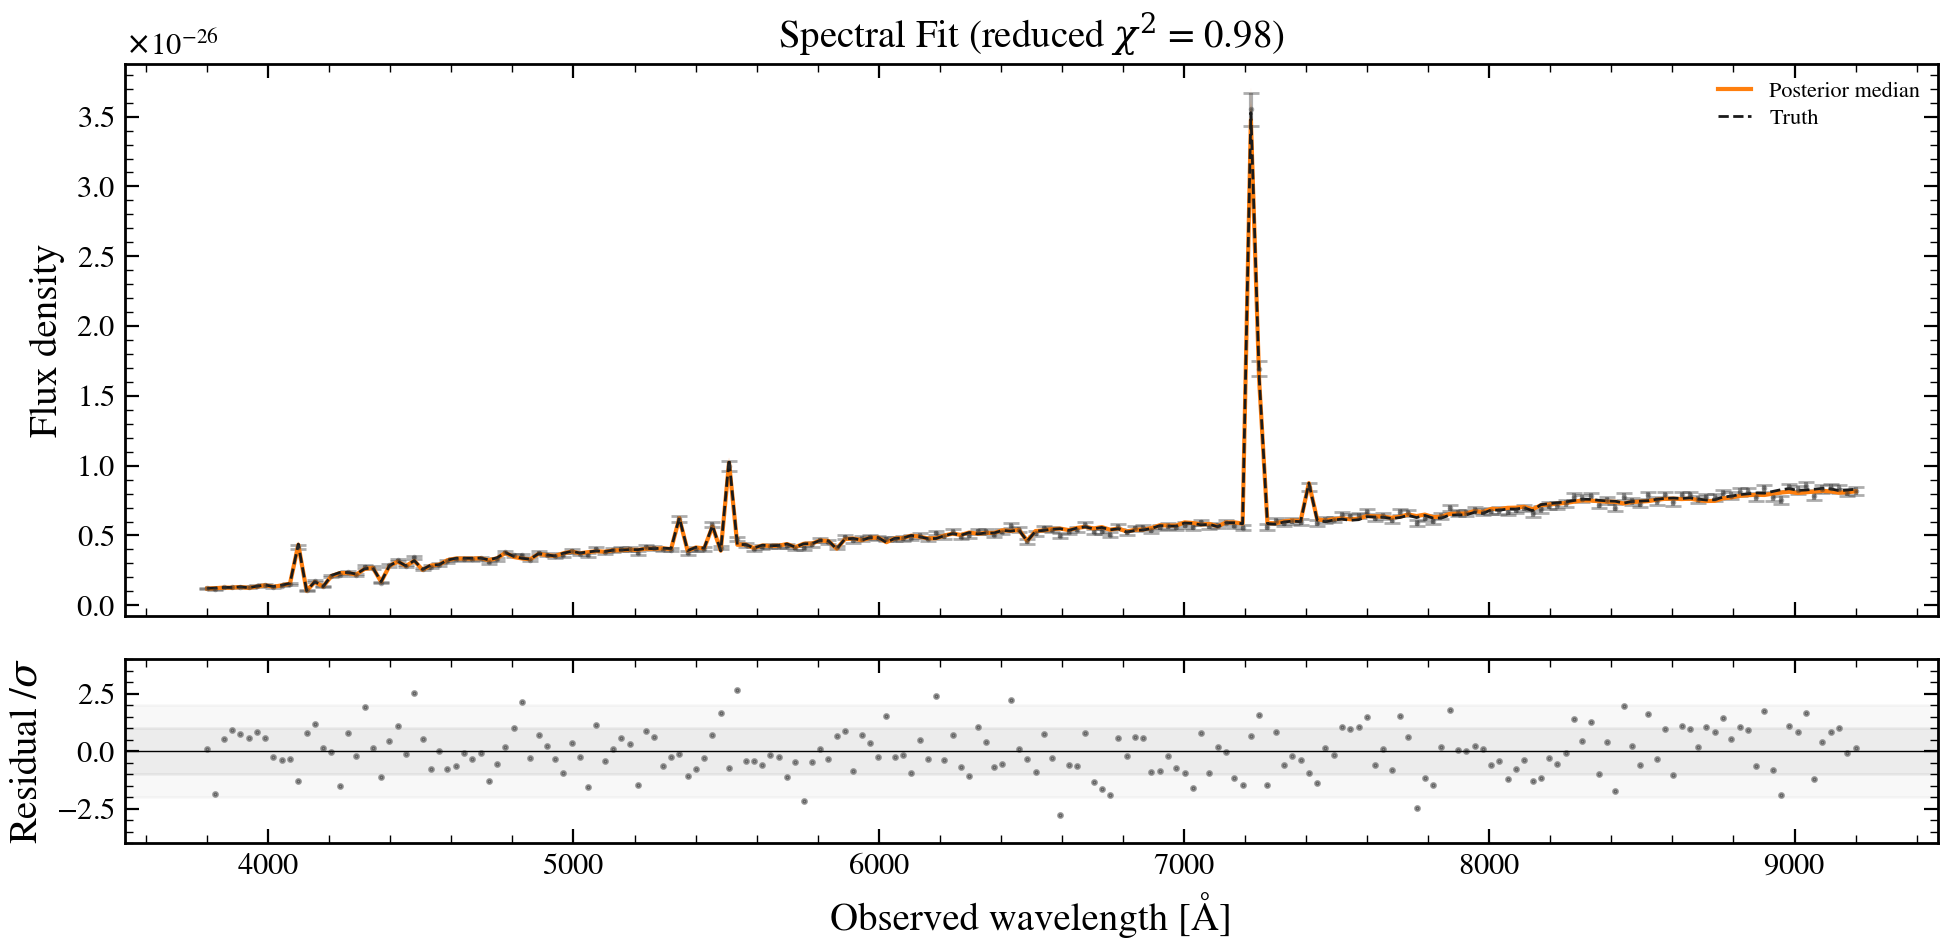

In [6]:
# --- FIGURE 2: Spectral fit + residuals ---
spec_draws = []
for i in range(50):
    idx = i % len(result_geovi_spec.samples[spec_param.free_params[0]])
    draw = {k: v[idx] for k, v in result_geovi_spec.samples.items()}
    spec_draws.append(np.array(model_param.predict_spectrum(draw)))
spec_draws = np.array(spec_draws)
spec_med = np.median(spec_draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.4,
)
for s in spec_draws[:50]:
    ax_f.plot(w, s, color=COLORS["geovi"], alpha=0.03, lw=0.5)
ax_f.plot(w, spec_med, color=COLORS["geovi"], lw=1.5, label="Posterior median")
ax_f.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1, ls="--", label="Truth")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(mock_spec.flux_obs) - spec_med) / np.array(mock_spec.noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.axhspan(-2, 2, alpha=0.05, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced $\\chi^2$ = {chi2:.2f})")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

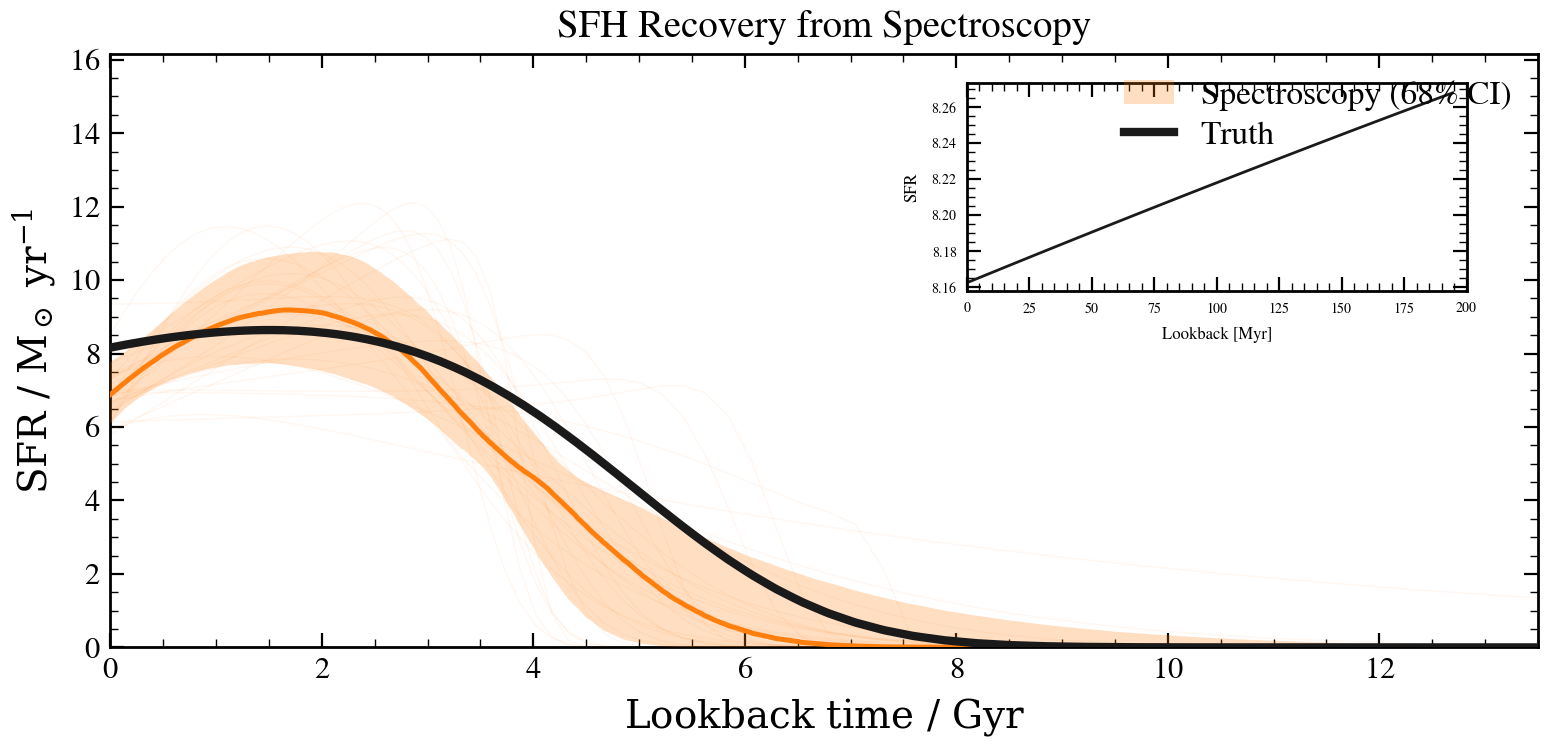

In [7]:
# --- FIGURE 3: SFH recovery ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_param,
    result_geovi_spec,
    true_params=true_param,
    ax=ax,
    color=COLORS["geovi"],
    label="Spectroscopy",
    method="geoVI",
)
ax.set_title("SFH Recovery from Spectroscopy")
# 200 Myr inset
sfh_true_p = model_param.predict_sfh(true_param)
t_gyr_p = np.array(sfh_true_p["t_gyr"])
sfr_p = np.array(sfh_true_p["sfr_mean"])
inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
mask_200 = t_gyr_p < 0.2
if hasattr(t_gyr_p, "__len__") and np.any(mask_200):
    inset.plot(t_gyr_p[mask_200] * 1e3, sfr_p[mask_200], color=COLORS["truth"], lw=1)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_sfh_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

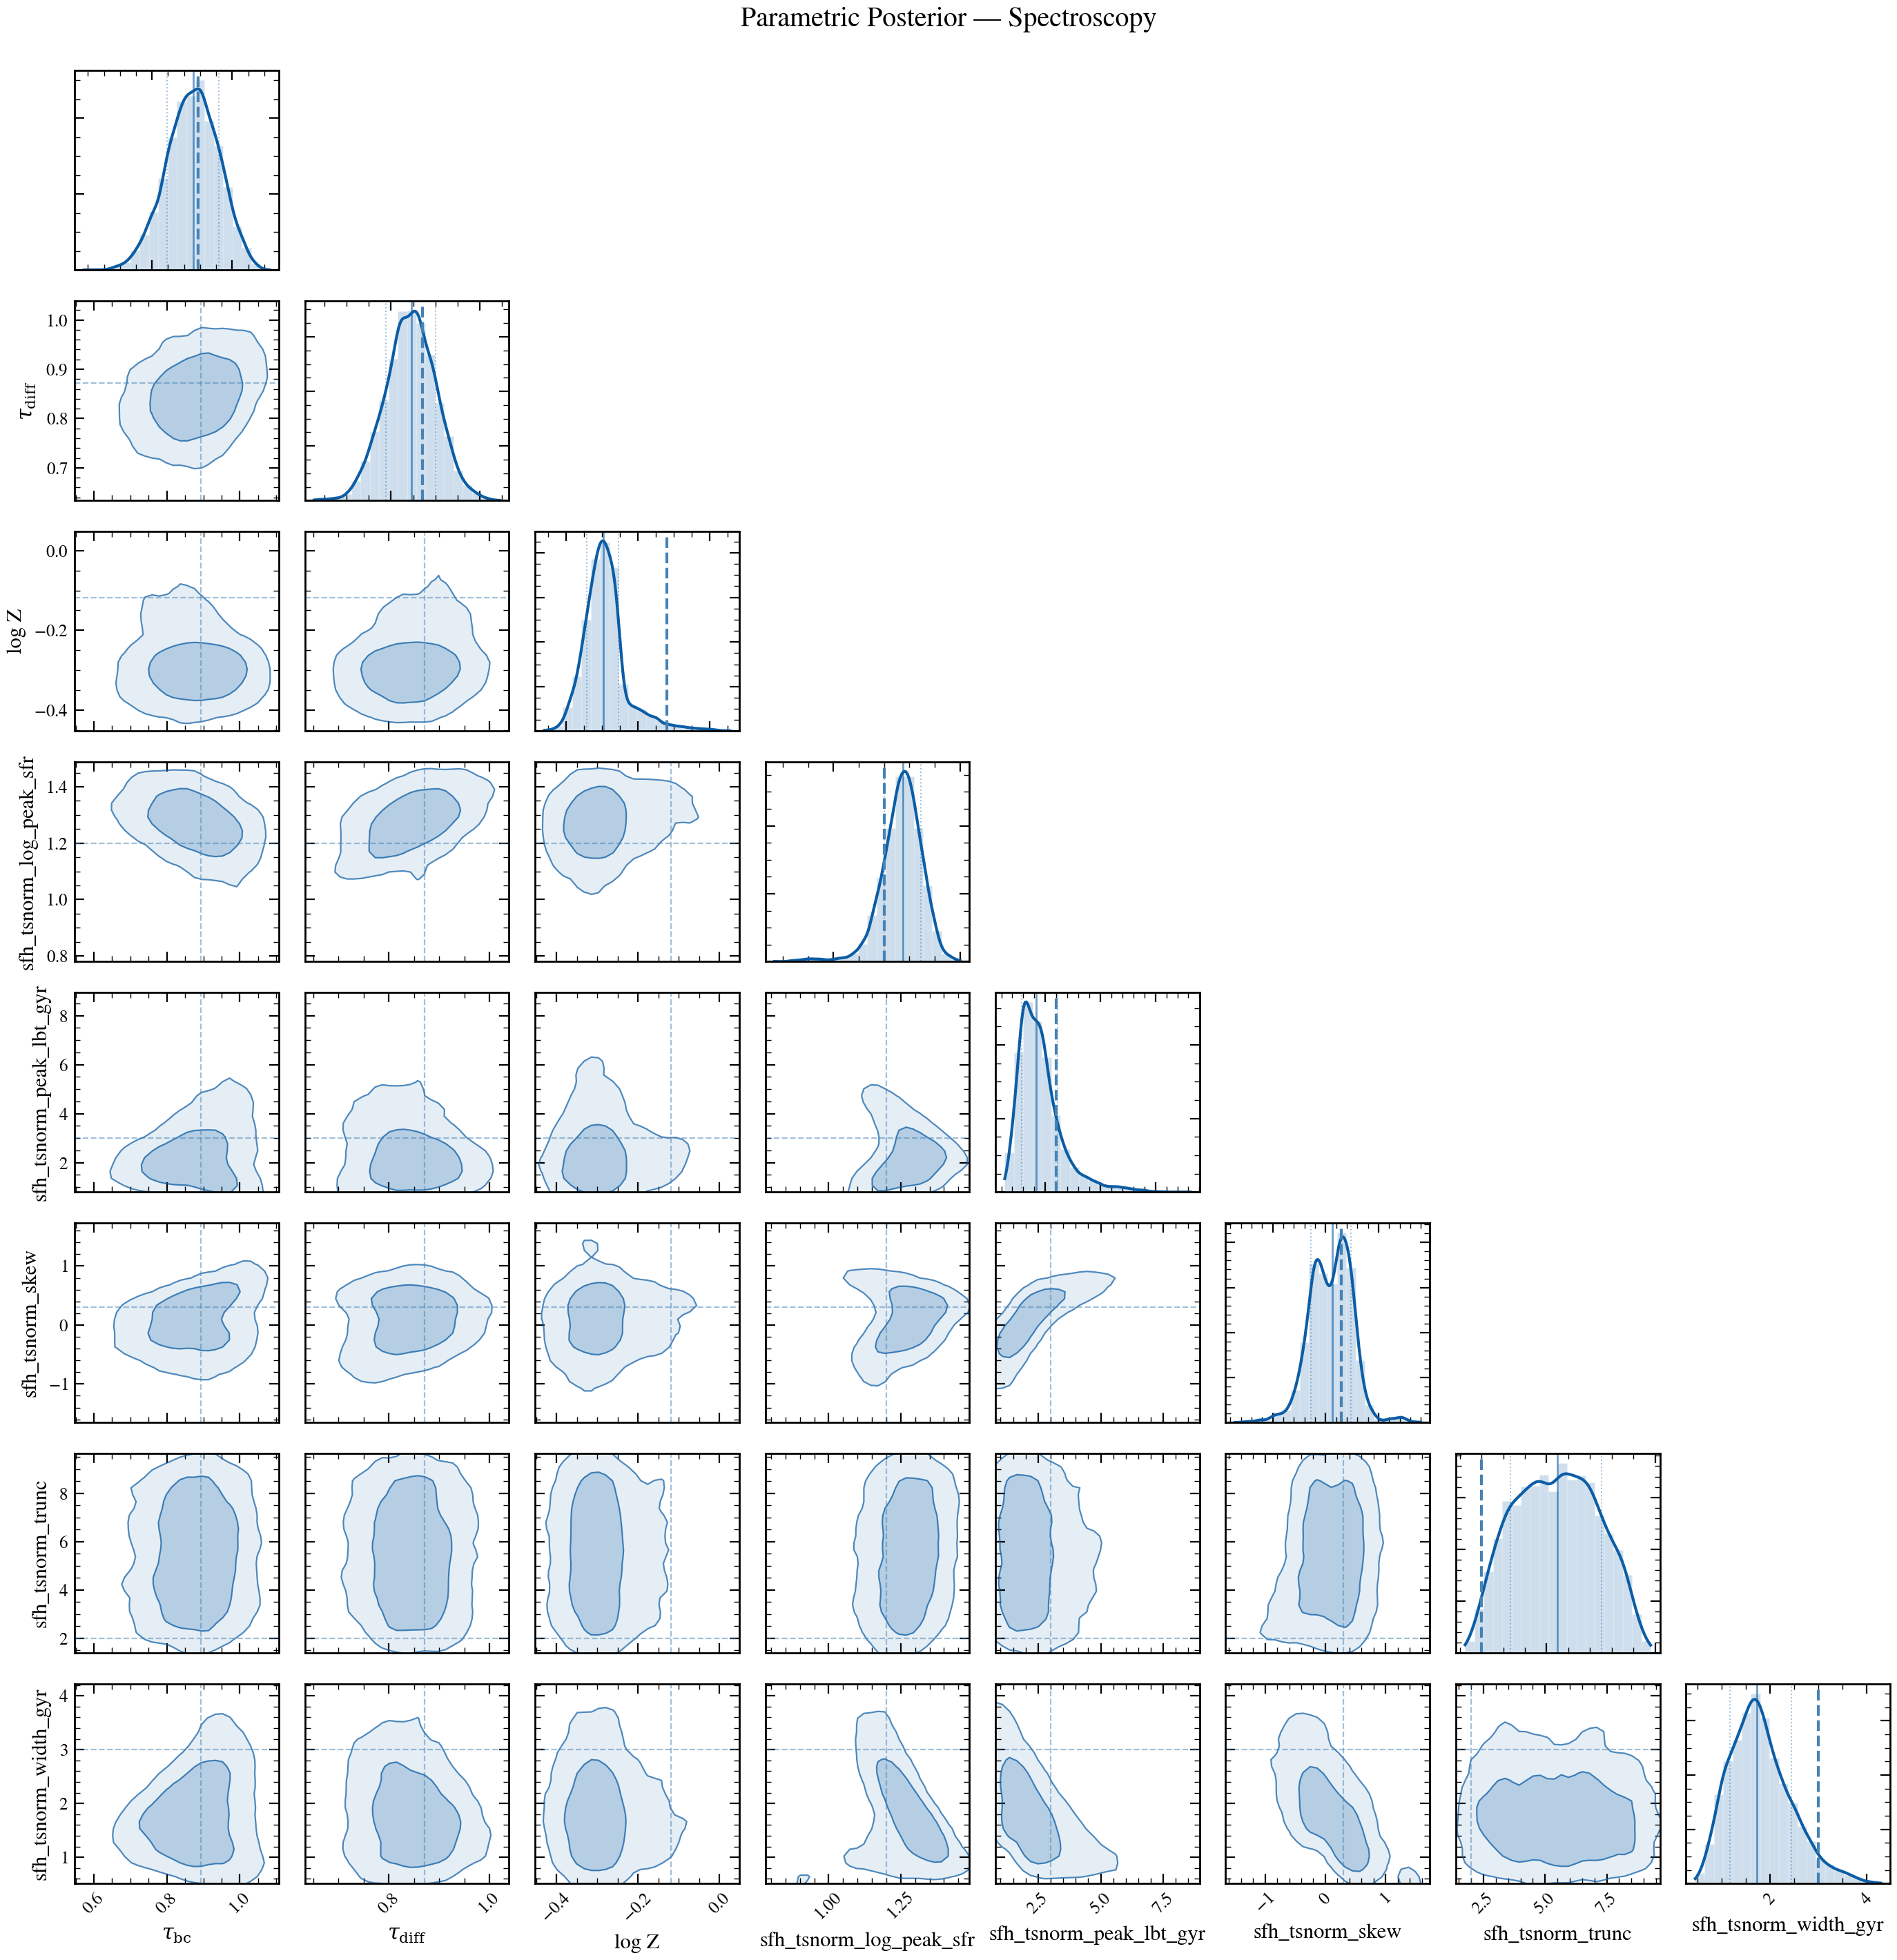

In [8]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result_geovi_spec, truths=true_param)
if fig is not None:
    fig.suptitle("Parametric Posterior — Spectroscopy", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig04_corner_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

## Laplace and Pathfinder: Fast Approximate Posteriors

Laplace inverts the Hessian at MAP; Pathfinder traces the L-BFGS path
and picks the best Gaussian along it (Zhang et al. 2022).

In [9]:
result_laplace = fitter_spec.run(
    "laplace",
    key=jax.random.PRNGKey(10),
    init_from=result_map,
    n_samples=5000,
    verbose=False,
)
result_pathfinder = fitter_spec.run(
    "pathfinder",
    key=jax.random.PRNGKey(11),
    init_from=result_map,
    n_samples=5000,
    verbose=False,
)
print(f"Laplace:    {result_laplace.wall_time_s:.1f}s")
print(f"Pathfinder: {result_pathfinder.wall_time_s:.1f}s")
print(f"geoVI:      {result_geovi_spec.wall_time_s:.1f}s")

Laplace:    7.7s
Pathfinder: 9.8s
geoVI:      54.3s


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

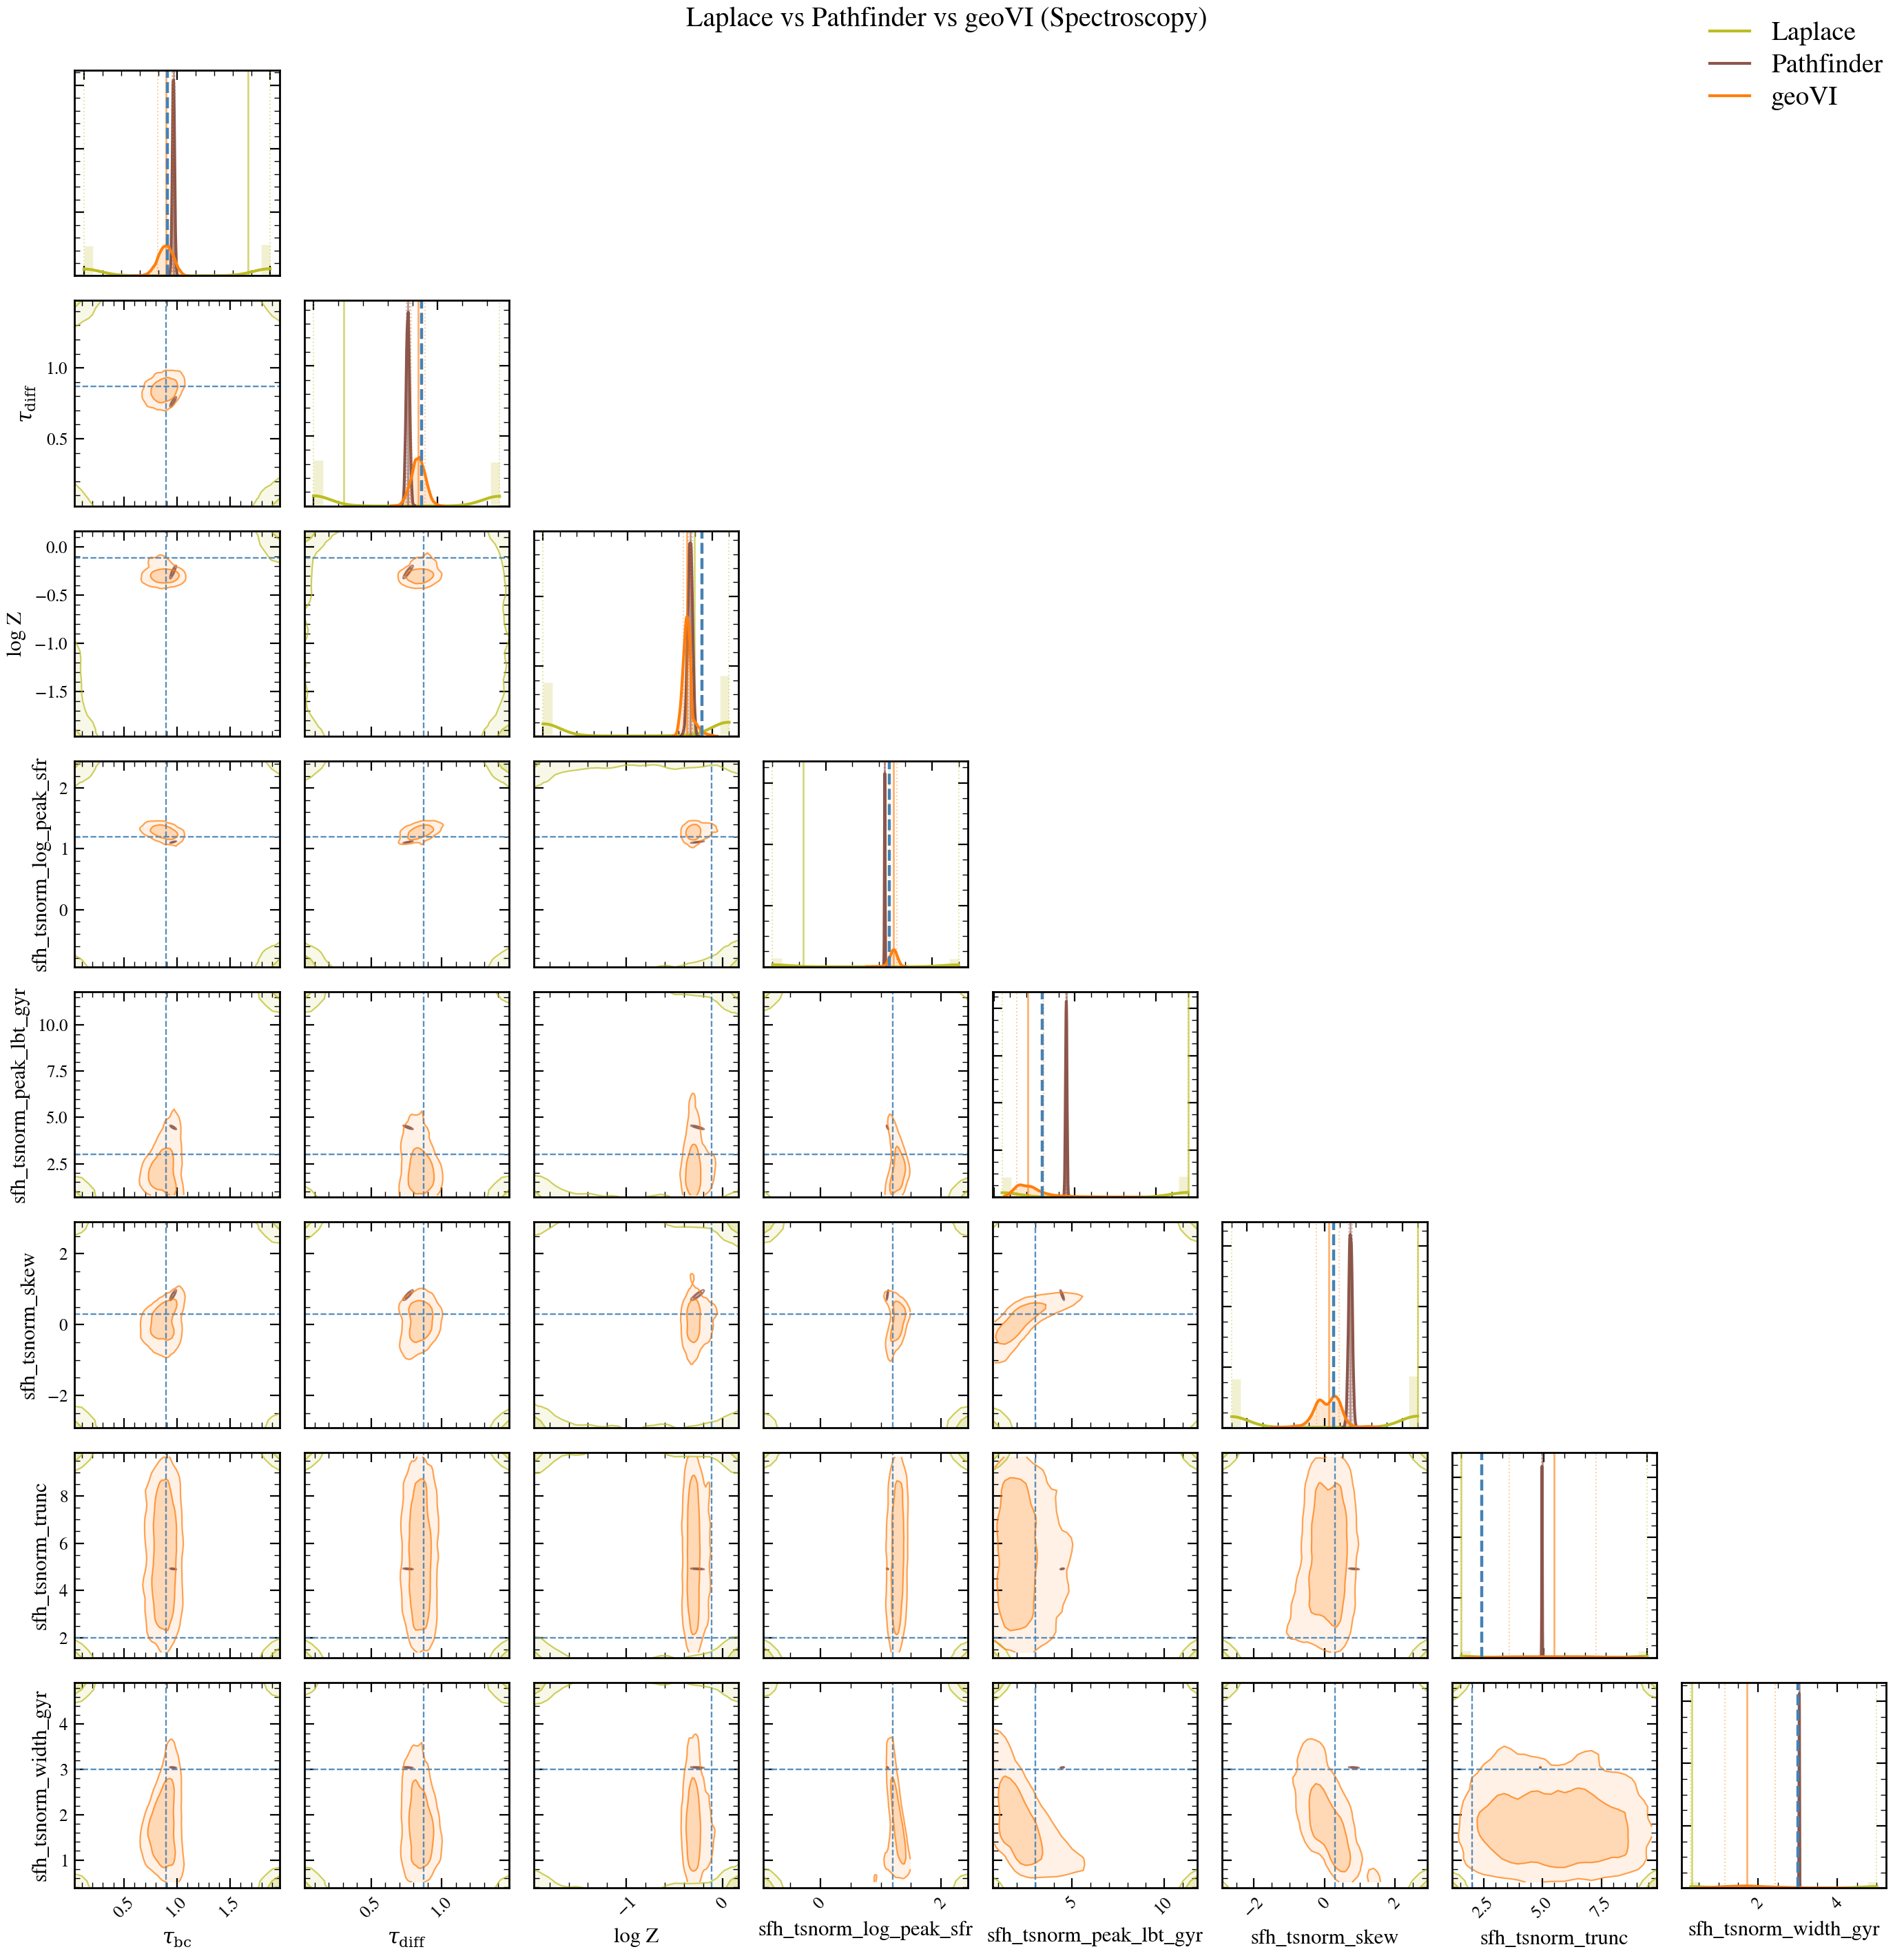

In [10]:
# --- FIGURE 4b: Corner — Laplace vs Pathfinder vs geoVI ---
fig = plot_corner_comparison(
    [result_laplace, result_pathfinder, result_geovi_spec],
    labels=["Laplace", "Pathfinder", "geoVI"],
    colors=[COLORS["laplace"], COLORS["pathfinder"], COLORS["geovi"]],
    truths=true_param,
)
if fig is not None:
    fig.suptitle("Laplace vs Pathfinder vs geoVI (Spectroscopy)", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig04b_laplace_pathfinder.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

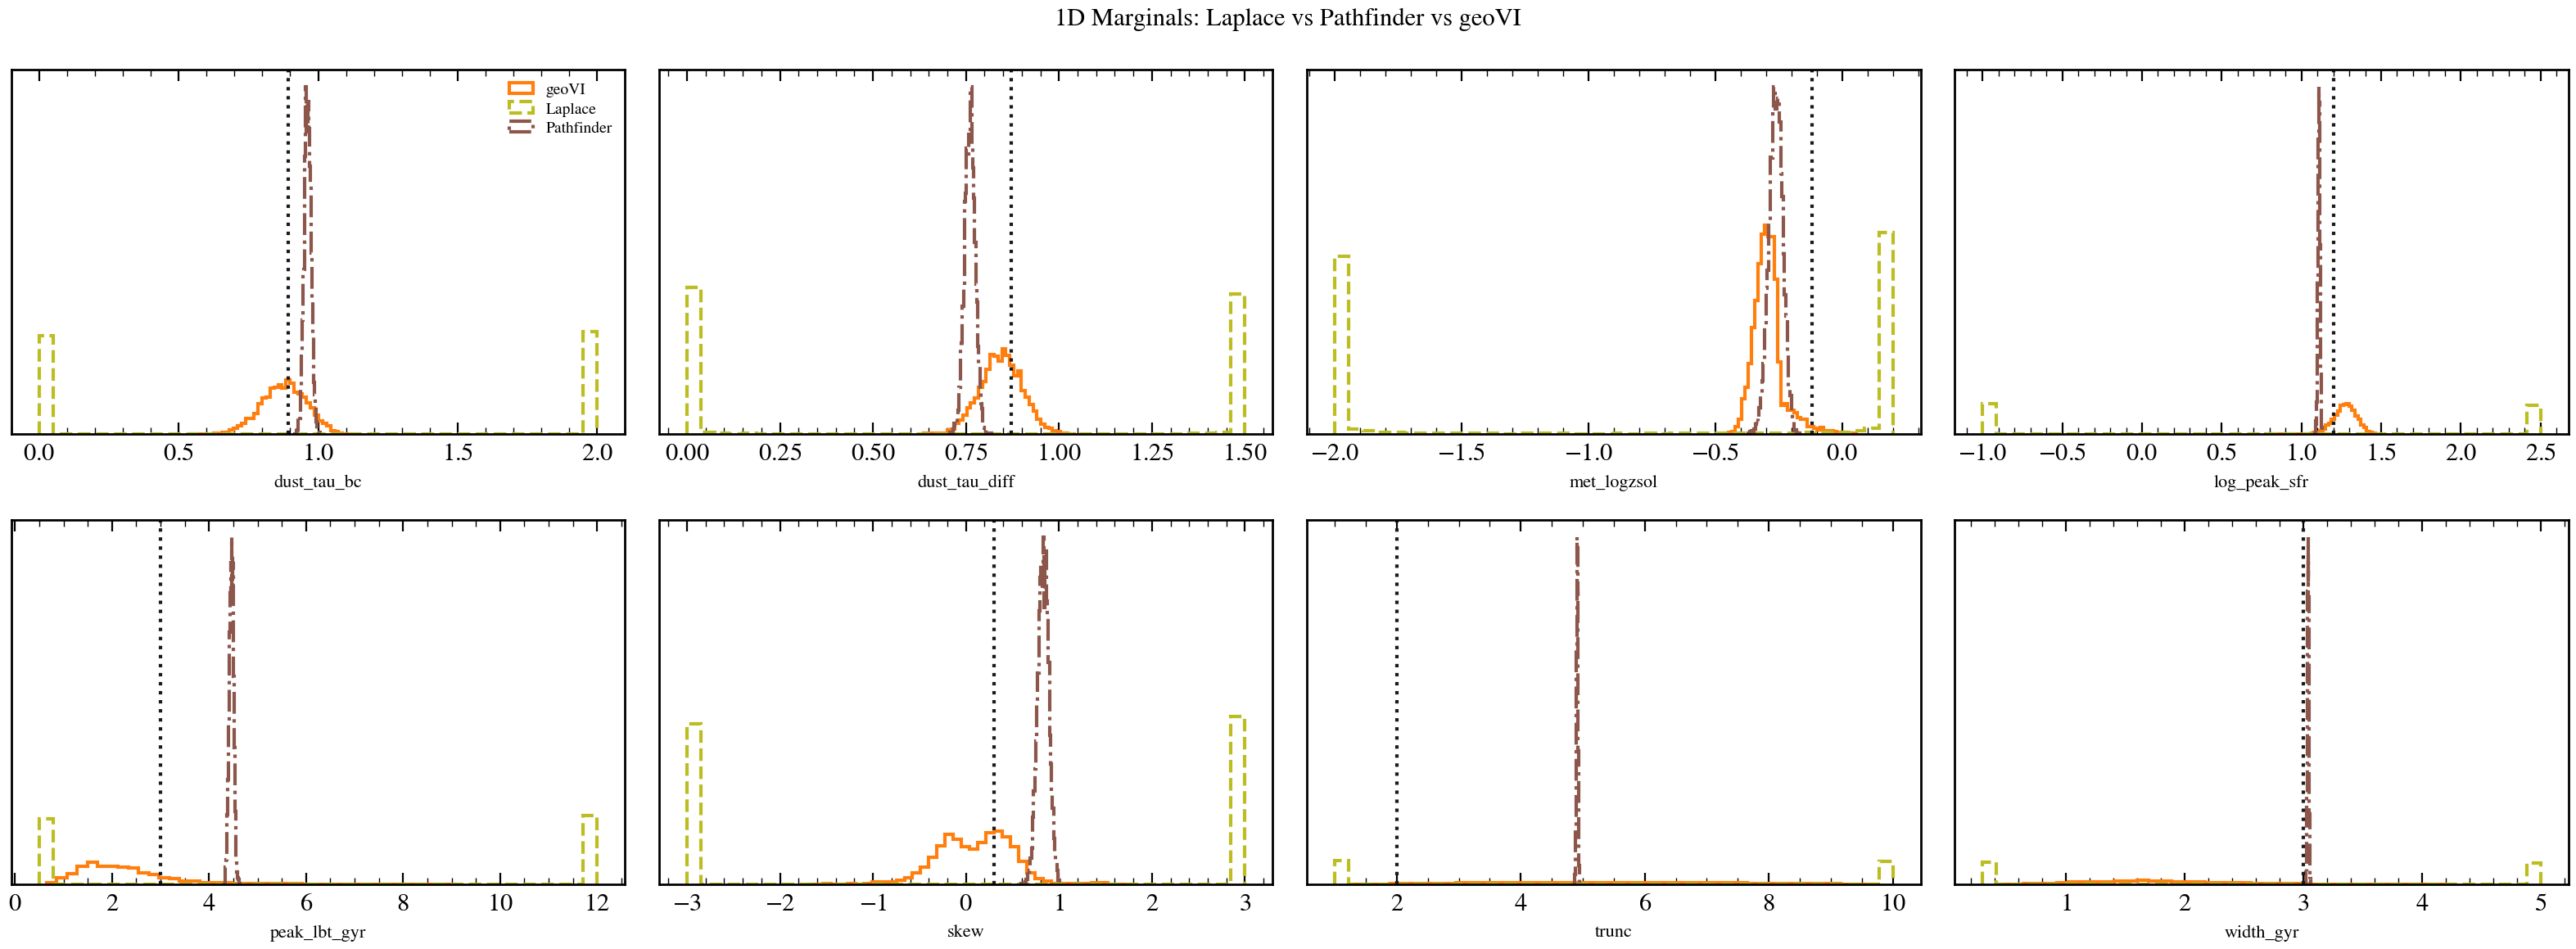

In [11]:
# --- FIGURE 4c: 1D marginals comparison ---
_free = spec_param.free_params
_ncols = min(4, len(_free))
_nrows = int(np.ceil(len(_free) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(4 * _ncols, 3 * _nrows))
_axes = np.array(axes).reshape(-1) if len(_free) > 1 else [axes]

for ax, pname in zip(_axes, _free):
    tv = float(true_param[pname])
    for label, res, color, ls in [
        ("geoVI", result_geovi_spec, COLORS["geovi"], "-"),
        ("Laplace", result_laplace, COLORS["laplace"], "--"),
        ("Pathfinder", result_pathfinder, COLORS["pathfinder"], "-."),
    ]:
        ax.hist(
            np.array(res.samples[pname]),
            bins=40,
            histtype="step",
            density=True,
            color=color,
            ls=ls,
            lw=1.5,
            label=label,
        )
    ax.axvline(tv, color=COLORS["truth"], lw=1.5, ls=":")
    ax.set_xlabel(pname.replace("sfh_tsnorm_", ""), fontsize=8)
    ax.set_yticks([])
for ax in _axes[len(_free) :]:
    ax.set_visible(False)
_axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("1D Marginals: Laplace vs Pathfinder vs geoVI", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04c_marginals.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Convergence diagnostics — parametric model
print(
    convergence_table(
        {
            "geoVI": result_geovi_spec,
            "Laplace": result_laplace,
            "Pathfinder": result_pathfinder,
        },
        verbose=True,
    )
)

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
geoVI               3939     4291      1.3        —        —         OK
Laplace             4364     4420      1.1        —        —         OK
Pathfinder          4188     4356      1.2        —        —         OK
{'geoVI': {'ess_min': 3938.703151380401, 'ess_median': 4291.287554826555, 'n_params_low_ess': 0, 'tau_max_max': 1.2694533728056265, 'tau_max_median': 1.1651847634775738, 'n_params_short_chain': 0, 'converged': True, 'warnings': []}, 'Laplace': {'ess_min': 4363.996253954578, 'ess_median': 4420.283736310354, 'n_params_low_ess': 0, 'tau_max_max': 1.145738838677757, 'tau_max_median': 1.1311633114276713, 'n_params_short_chain': 0, 'converged': True, 'warnings': []}, 'Pathfinder': {'ess_min': 4187.568913208017, 'ess_median': 4355.510874575259, 'n_params_low_ess': 0, 'tau_max_max': 1.194010201057108, 'tau_max_median': 1.1479893943652453, '

In [13]:
# Parameter recovery table — parametric D=7
print(f"\n{'Parameter':<32s} {'True':>8s} {'Median':>8s} {'16%':>8s} {'84%':>8s} {'Status':>6s}")
print("-" * 76)
for name in spec_param.free_params:
    truth = float(true_param[name])
    lo, med, hi = np.percentile(result_geovi_spec.samples[name], [16, 50, 84])
    covered = "ok" if lo <= truth <= hi else "MISS"
    print(f"  {name:<30s} {truth:8.3f} {med:8.3f} {lo:8.3f} {hi:8.3f} {covered:>6s}")


Parameter                            True   Median      16%      84% Status
----------------------------------------------------------------------------
  dust_tau_bc                       0.893    0.879    0.797    0.958     ok
  dust_tau_diff                     0.871    0.845    0.788    0.901     ok
  met_logzsol                      -0.119   -0.297   -0.344   -0.254   MISS
  sfh_tsnorm_log_peak_sfr           1.200    1.275    1.200    1.344   MISS
  sfh_tsnorm_peak_lbt_gyr           3.000    2.082    1.420    3.059     ok
  sfh_tsnorm_skew                   0.300    0.127   -0.277    0.475     ok
  sfh_tsnorm_trunc                  2.000    5.483    3.330    7.534   MISS
  sfh_tsnorm_width_gyr              3.000    1.724    1.162    2.430   MISS


## Stochastic SFH from Spectroscopy

Spectroscopy breaks the σ–τ degeneracy that photometry can't. The rich
spectral information constrains both the amplitude and timescale of
burstiness.

In [14]:
# Stochastic model
spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, observation=obs_joint)
model_stoch_spec = Model(spec_stoch, ssp_data, observation=obs_spec)

true_stoch = spec_stoch.sample(jax.random.PRNGKey(77))
# Override to a typical star-forming galaxy with burstiness
true_stoch = {**true_stoch}
true_stoch["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_stoch["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_stoch["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_stoch["sfh_tsnorm_skew"] = jnp.array(0.3)
true_stoch["sfh_tsnorm_trunc"] = jnp.array(2.0)
true_stoch["sfh_field_psd_sigma"] = jnp.array(2.0)
true_stoch["sfh_field_psd_tau_myr"] = jnp.array(20.0)

mock_spec_s = model_stoch.mock_spectrum(true_stoch, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(78))
mock_phot_s = model_stoch.mock(true_stoch, snr=20.0, key=jax.random.PRNGKey(79))

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78382/574668435.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, observation=obs_joint)
<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


In [15]:
fitter_stoch_spec = Fitter(model_stoch_spec, mock_spec_s.flux_obs, mock_spec_s.noise)

t0_compile = time.perf_counter()
fitter_stoch_spec.compile(verbose=False)
t_compile = time.perf_counter() - t0_compile

_ = fitter_stoch_spec.run("map", n_steps=1000, verbose=False)

t0 = time.perf_counter()
result_stoch_spec = fitter_stoch_spec.run(
    "vi",
    n_iterations=20,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=5000,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"Stochastic spectroscopic fit (D = {spec_stoch.n_free}):")
print(f"  XLA compile: {t_compile:.1f}s (one-time, cached on disk)")
print(f"  native_geovi: {t_run:.1f}s <- runtime per galaxy")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:36:34.751447 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:36:36.608779 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 02:36:53.044081 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:36:54.156548 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:37:12.696389 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:37:26.002382 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Stochastic spectroscopic fit (D = 10):
  XLA compile: 20.5s (one-time, cached on disk)
  native_geovi: 62.1s <- runtime per galaxy


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78382/3571453218.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


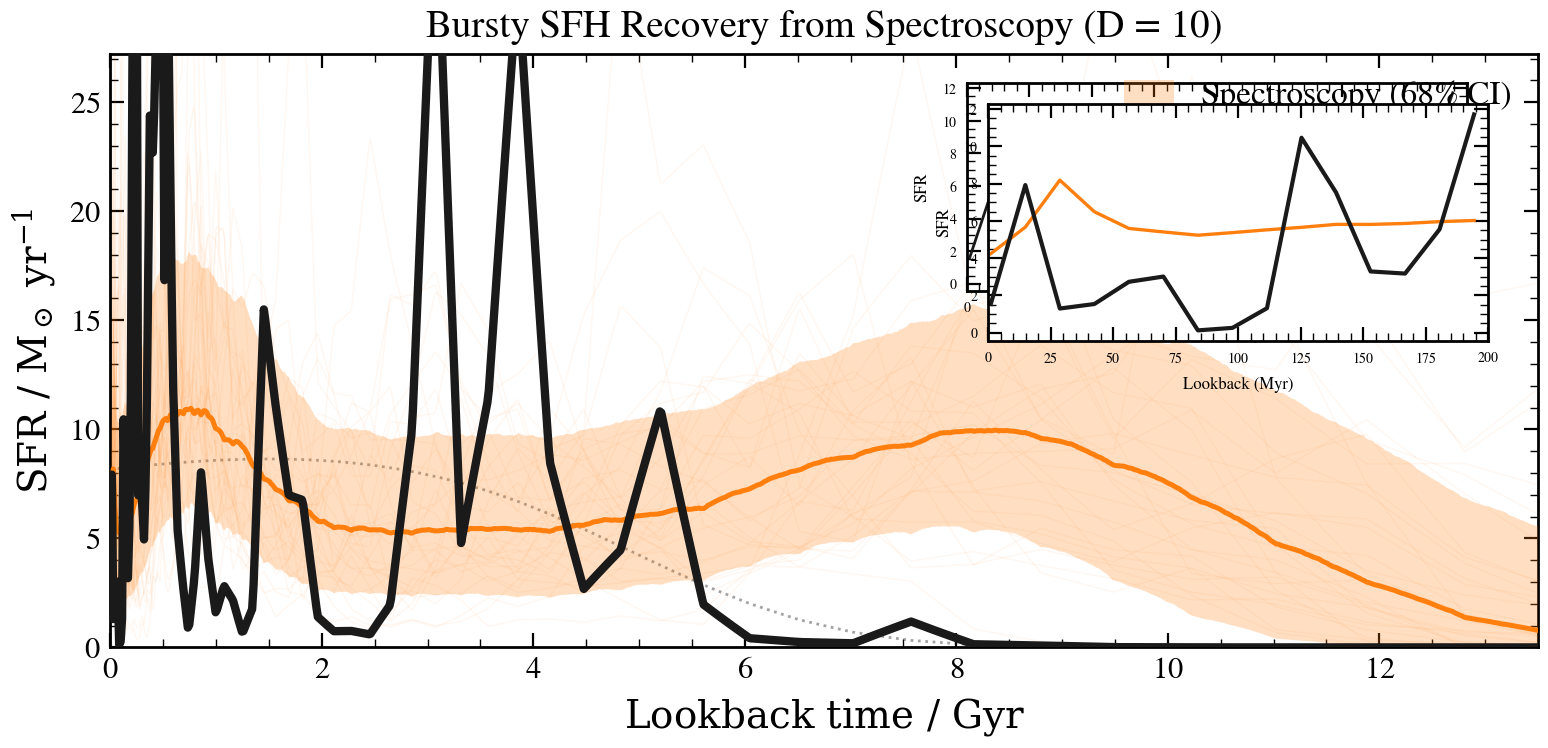

In [16]:
# --- FIGURE 5: Bursty SFH recovery from spectroscopy ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_stoch,
    result_stoch_spec,
    true_params=true_stoch,
    ax=ax,
    color=COLORS["geovi"],
    label="Spectroscopy",
    method="geoVI",
    show_mean_sfh=True,
)
ax.set_title(f"Bursty SFH Recovery from Spectroscopy (D = {spec_stoch.n_free})")
# 200 Myr inset
sfh_true_s = model_stoch.predict_sfh(true_stoch)
t_gyr_s = np.array(sfh_true_s["t_gyr"])
sfr_full_s = np.array(sfh_true_s["sfr_full"])
inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
mask_200 = t_gyr_s < 0.2
if hasattr(t_gyr_s, "__len__") and np.any(mask_200):
    inset.plot(t_gyr_s[mask_200] * 1e3, sfr_full_s[mask_200], color=COLORS["truth"], lw=1)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_sfh_bursty_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

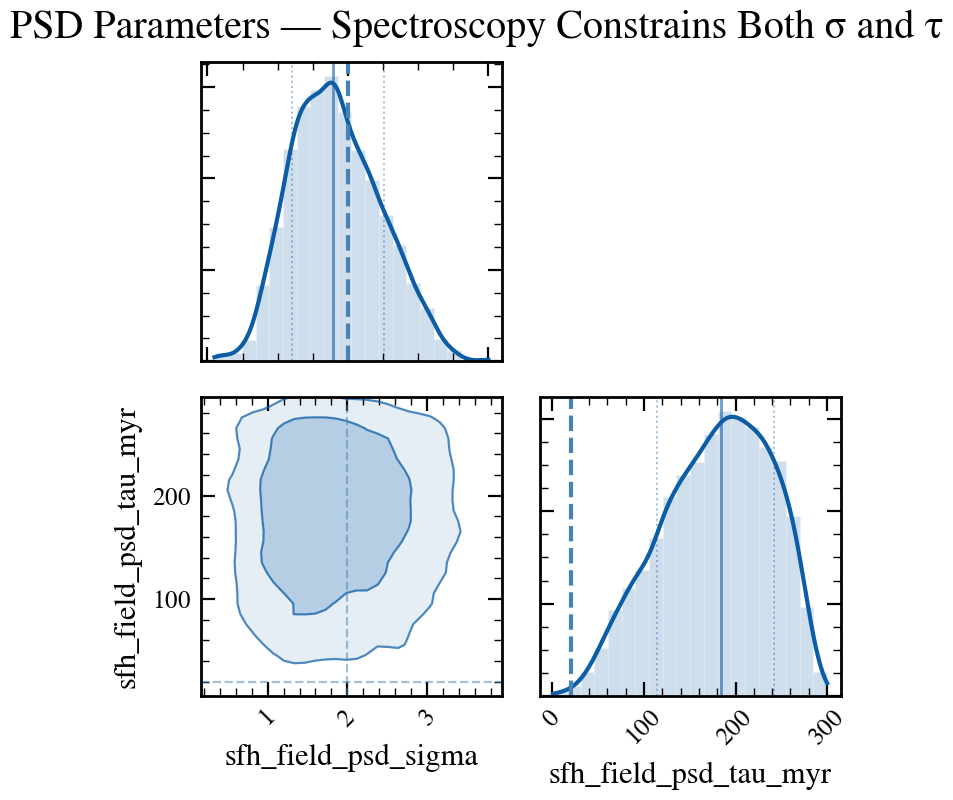

In [17]:
# --- FIGURE 6: PSD parameter corner ---
psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
fig = safe_corner(result_stoch_spec, truths=true_stoch, params=psd_params)
if fig is not None:
    fig.suptitle("PSD Parameters — Spectroscopy Constrains Both σ and τ", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig06_psd_corner.png"), dpi=150, bbox_inches="tight")
plt.show()

## Photometry vs Spectroscopy: Head-to-Head

We fit the same galaxy with 5-band SDSS photometry and compare posteriors.

In [18]:
# Fit photometry — separate model with photometry-only observation
model_stoch_phot = Model(spec_stoch, ssp_data, observation=obs_phot)
fitter_stoch_phot = Fitter(model_stoch_phot, mock_phot_s.flux_obs, mock_phot_s.noise)
_ = fitter_stoch_phot.run("map", n_steps=1000, verbose=False)
result_stoch_phot = fitter_stoch_phot.run(
    "vi",
    n_iterations=20,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=5000,
    verbose=False,
)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_78382/1319403791.py:2: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch_phot = Model(spec_stoch, ssp_data, observation=obs_phot)


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:38:20.120479 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:38:21.888683 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:38:40.746110 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 32.9 ± 54.0 (CV=164%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 02:38:51.738795 36237373 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=6.7 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

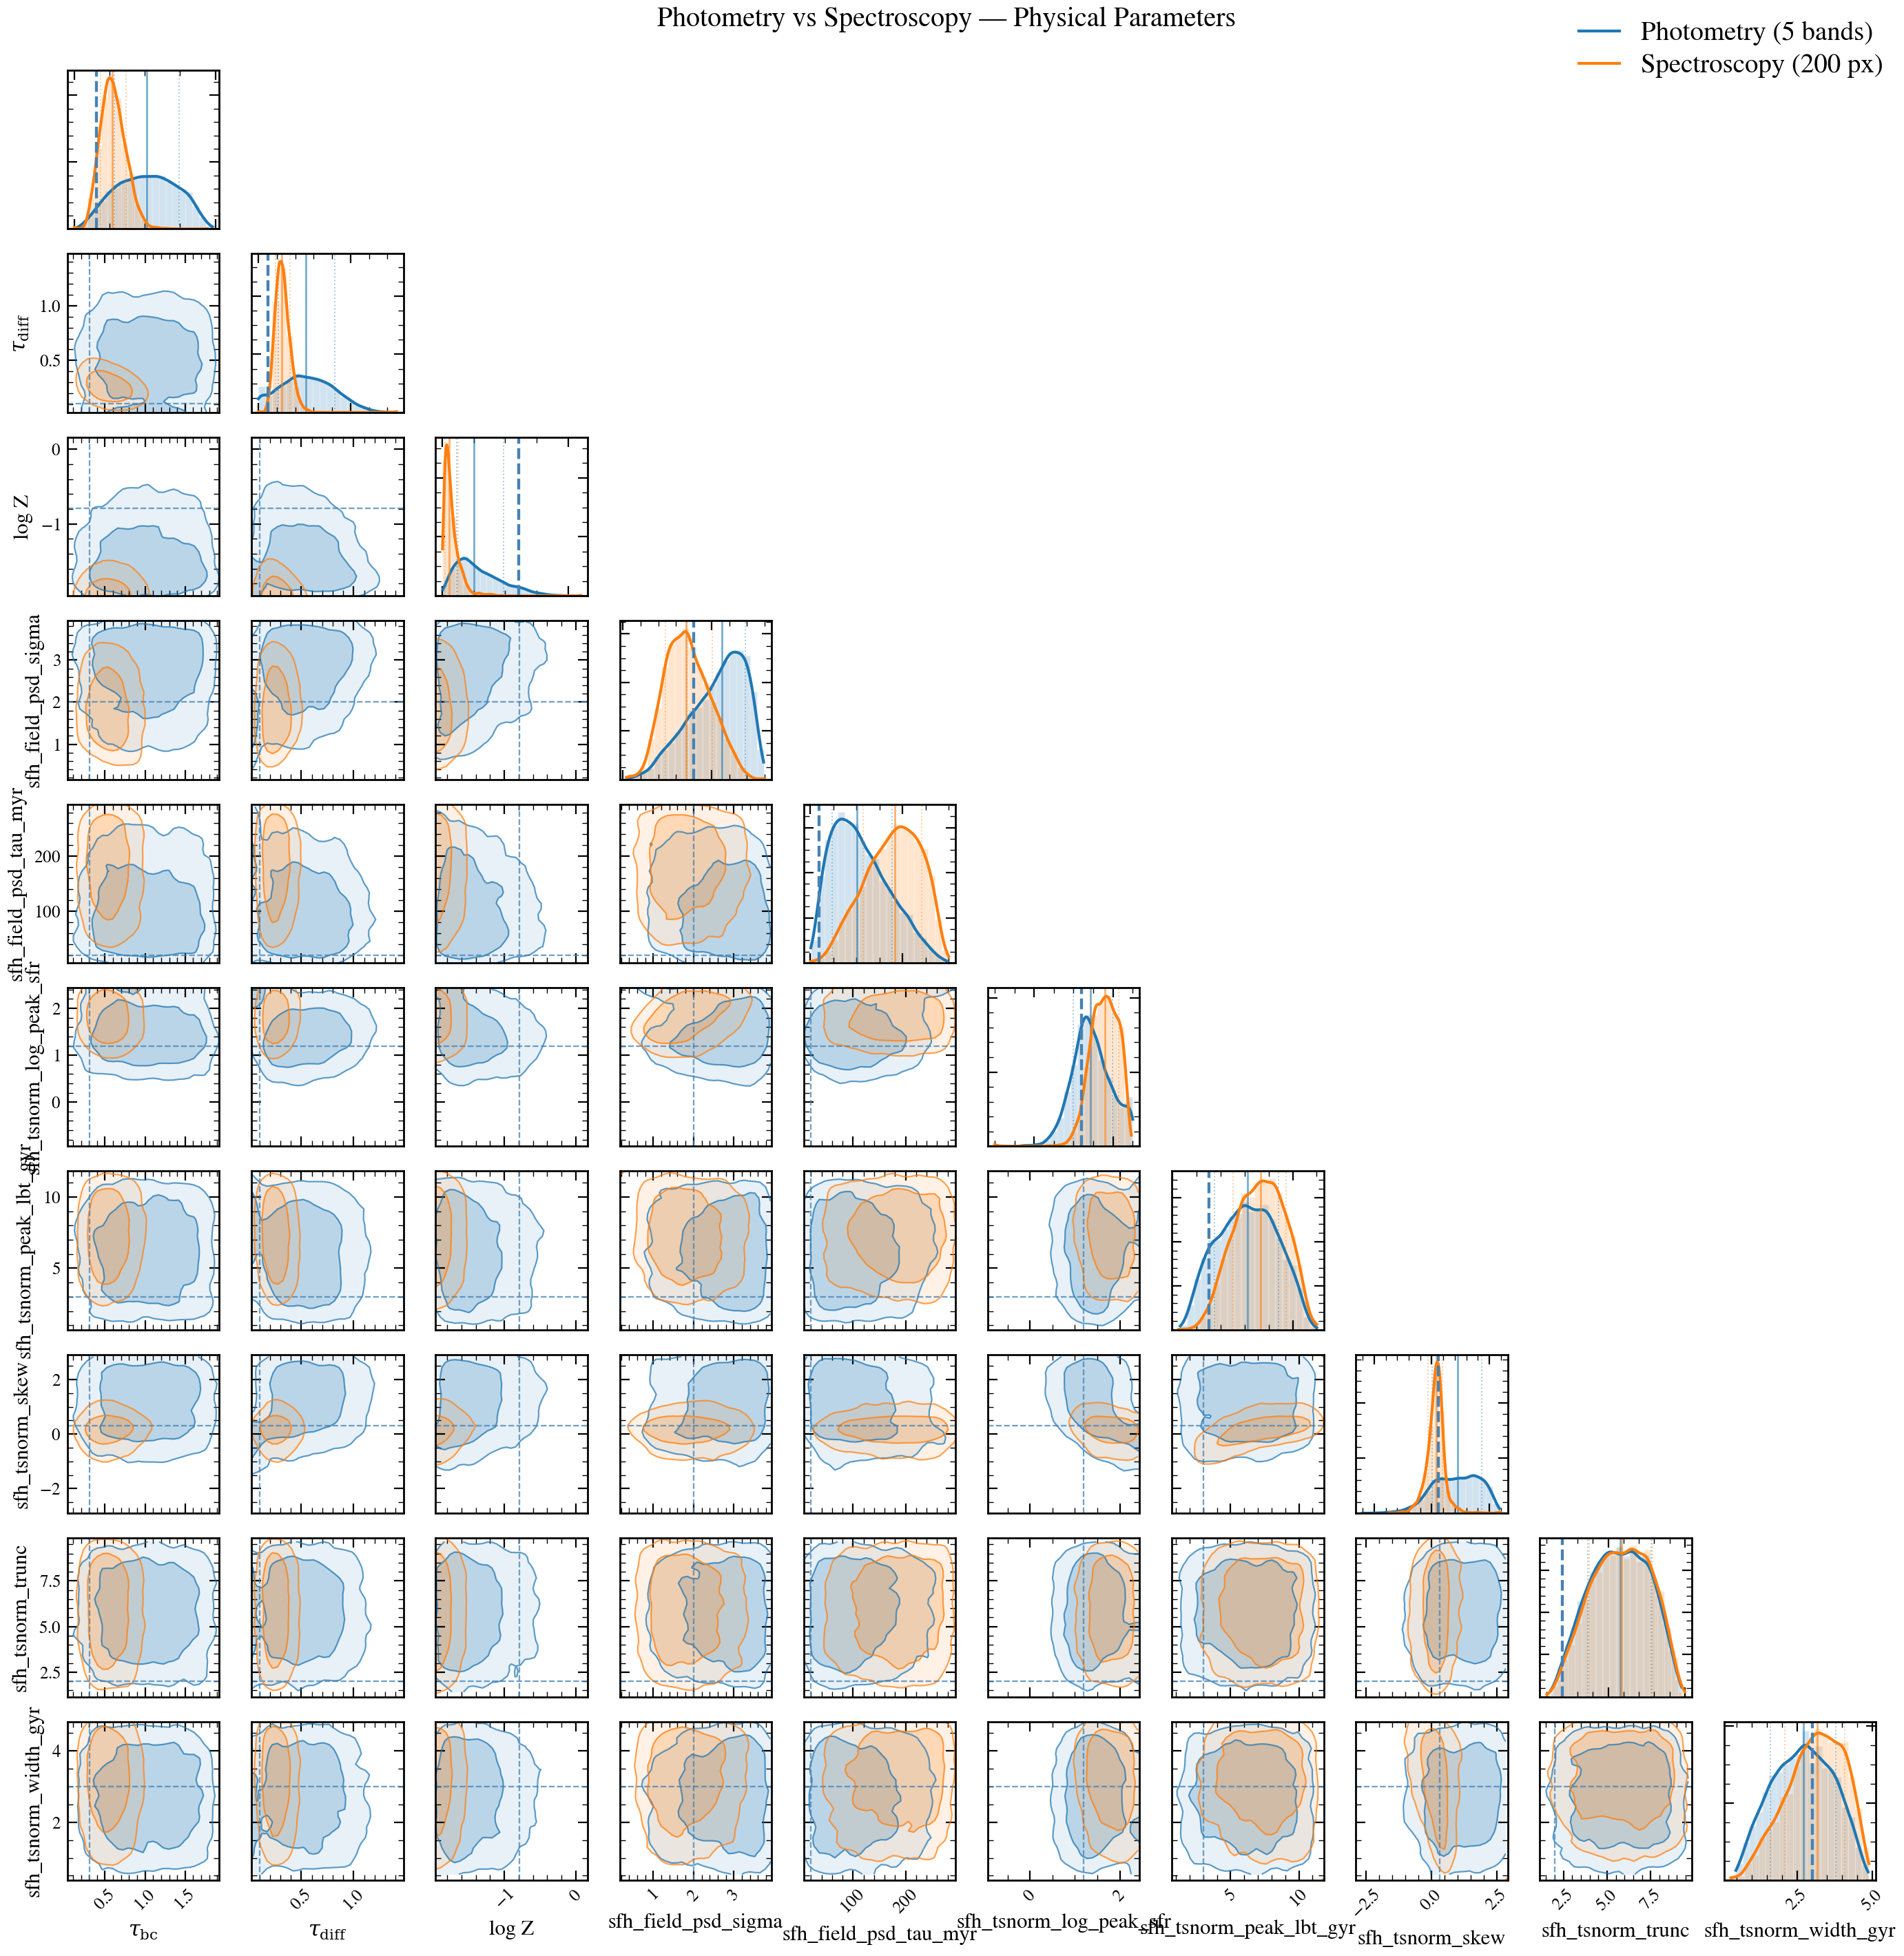

In [19]:
# --- FIGURE 7: Overlaid corners (phot vs spec) ---
phys_params = [p for p in spec_stoch.free_params if "xi" not in p]
fig = plot_corner_comparison(
    [result_stoch_phot, result_stoch_spec],
    labels=["Photometry (5 bands)", "Spectroscopy (200 px)"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_stoch,
    params=phys_params,
)
if fig is not None:
    fig.suptitle("Photometry vs Spectroscopy — Physical Parameters", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig07_phot_vs_spec_corner.png"), dpi=150, bbox_inches="tight"
    )
plt.show()

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

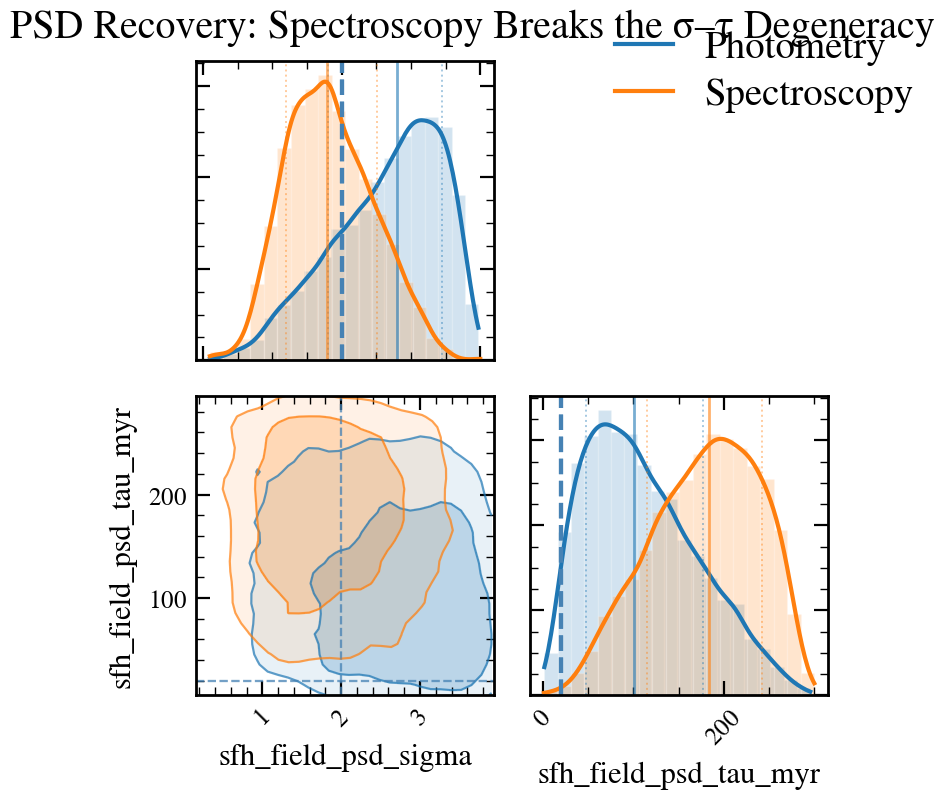

In [20]:
# --- FIGURE 8: PSD corner comparison ---
fig = plot_corner_comparison(
    [result_stoch_phot, result_stoch_spec],
    labels=["Photometry", "Spectroscopy"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_stoch,
    params=psd_params,
)
if fig is not None:
    fig.suptitle("PSD Recovery: Spectroscopy Breaks the σ–τ Degeneracy", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig08_psd_phot_vs_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# CI width comparison table
print("\n  Parameter                  | Phot CI   | Spec CI   | Improvement")
print("  " + "-" * 65)
for p in phys_params:
    s_phot = np.array(result_stoch_phot.samples[p])
    s_spec = np.array(result_stoch_spec.samples[p])
    w_phot = np.percentile(s_phot, 84) - np.percentile(s_phot, 16)
    w_spec = np.percentile(s_spec, 84) - np.percentile(s_spec, 16)
    ratio = w_phot / max(w_spec, 1e-10)
    print(f"  {p:<28s} | {w_phot:>7.3f}  | {w_spec:>7.3f}  | {ratio:>5.1f}×")


  Parameter                  | Phot CI   | Spec CI   | Improvement
  -----------------------------------------------------------------
  dust_tau_bc                  |   0.920  |   0.355  |   2.6×
  dust_tau_diff                |   0.612  |   0.154  |   4.0×
  met_logzsol                  |   0.749  |   0.203  |   3.7×
  sfh_field_psd_sigma          |   1.650  |   1.314  |   1.3×
  sfh_field_psd_tau_myr        | 130.251  | 126.975  |   1.0×
  sfh_tsnorm_log_peak_sfr      |   0.991  |   0.723  |   1.4×
  sfh_tsnorm_peak_lbt_gyr      |   5.342  |   4.387  |   1.2×
  sfh_tsnorm_skew              |   2.134  |   0.618  |   3.5×
  sfh_tsnorm_trunc             |   4.135  |   4.103  |   1.0×
  sfh_tsnorm_width_gyr         |   2.176  |   2.008  |   1.1×


## SNR Dependence

In [22]:
# Fit at SNR = 10, 30, 100
snr_results = {}
for snr in [10, 30, 100]:
    mock_snr = model_param.mock_spectrum(
        true_param, WAVE_OBS, snr=float(snr), key=jax.random.PRNGKey(snr)
    )
    fitter_snr = Fitter(model_param_spec, mock_snr.flux_obs, mock_snr.noise)
    _ = fitter_snr.run("map", n_steps=500, verbose=False)
    res_snr = fitter_snr.run(
        "vi",
        n_iterations=15,
        n_samples=6,
        n_seeds=3,
        n_posterior_samples=2000,
        verbose=False,
    )
    snr_results[snr] = res_snr
    print(f"SNR = {snr}: {res_snr.wall_time_s:.1f}s")

SNR = 10: 12.2s


SNR = 30: 13.1s


SNR = 100: 13.9s


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Parameters near bounds: sfh_tsnorm_peak_lbt_gyr. Consider widening the prior.
  return run_native_vi(self, key=key, **kwargs)


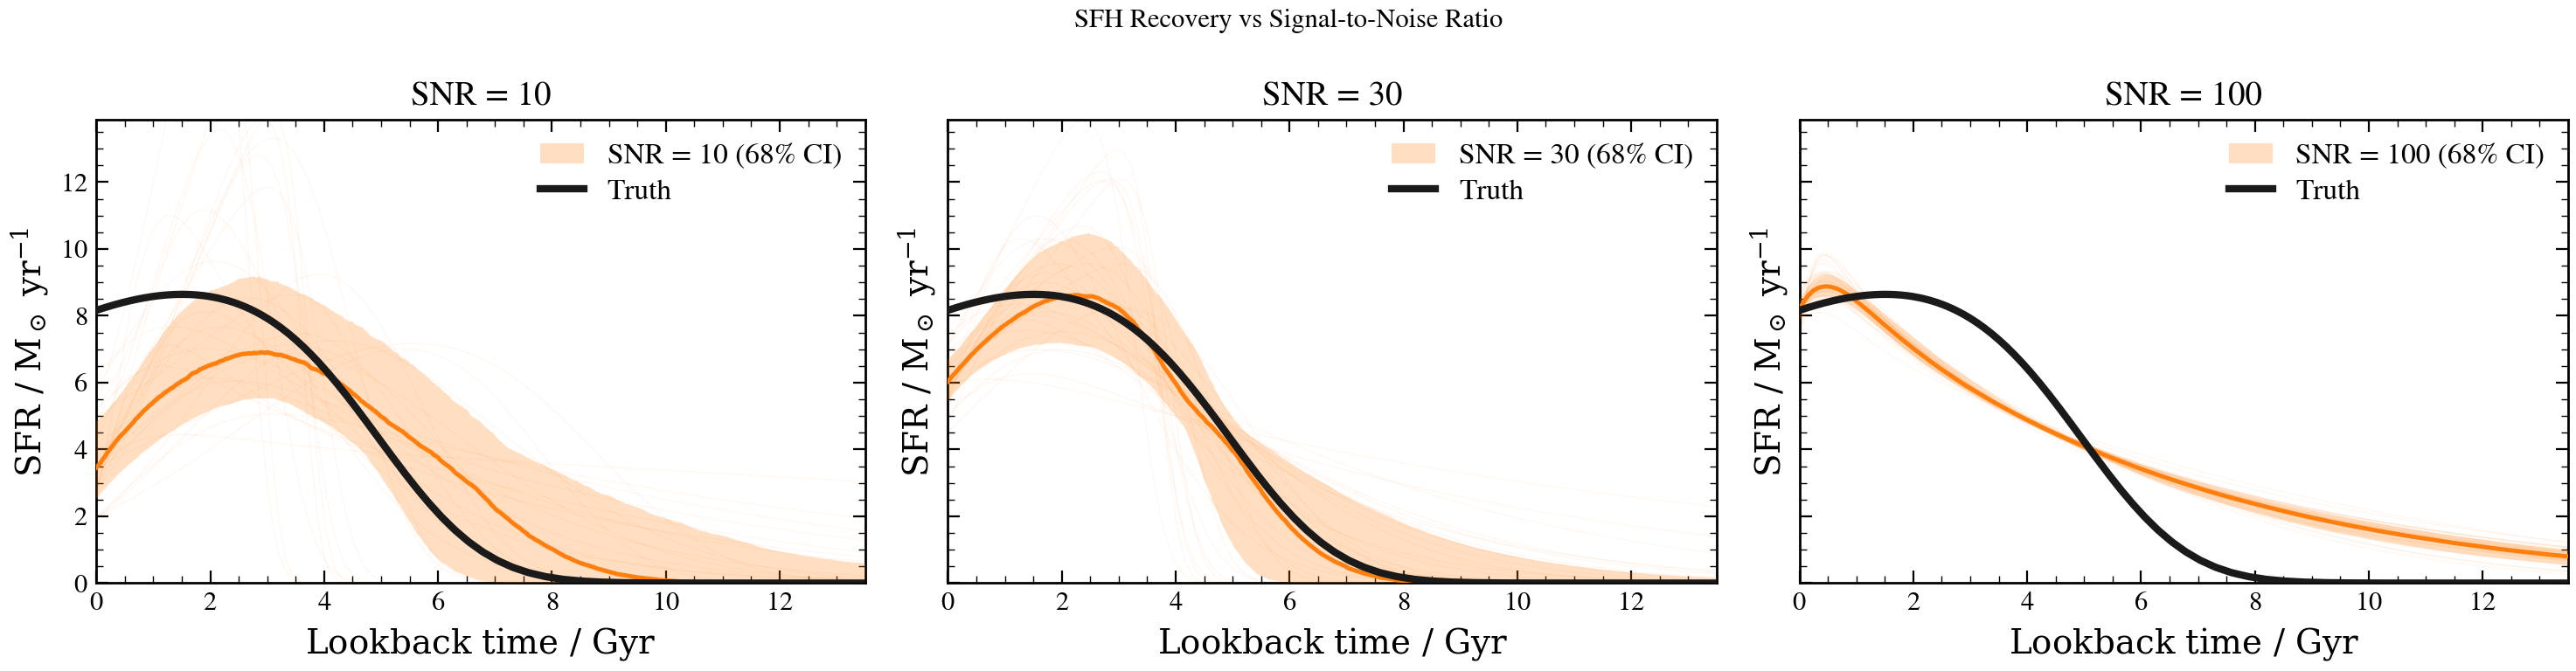

In [23]:
# --- FIGURE 9: SFH recovery at 3 SNR values ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, snr in zip(axes, [10, 30, 100]):
    plot_sfh(
        model_param,
        snr_results[snr],
        true_params=true_param,
        ax=ax,
        color=COLORS["geovi"],
        label=f"SNR = {snr}",
        method="geoVI",
    )
    ax.set_title(f"SNR = {snr}")
fig.suptitle("SFH Recovery vs Signal-to-Noise Ratio", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig09_snr_dependence.png"), dpi=150, bbox_inches="tight")
plt.show()

## Feature Accessibility vs Redshift

As redshift increases, different spectral features shift through the
observed window. At z > 5, the Lyman break enters the NIR — JWST territory.

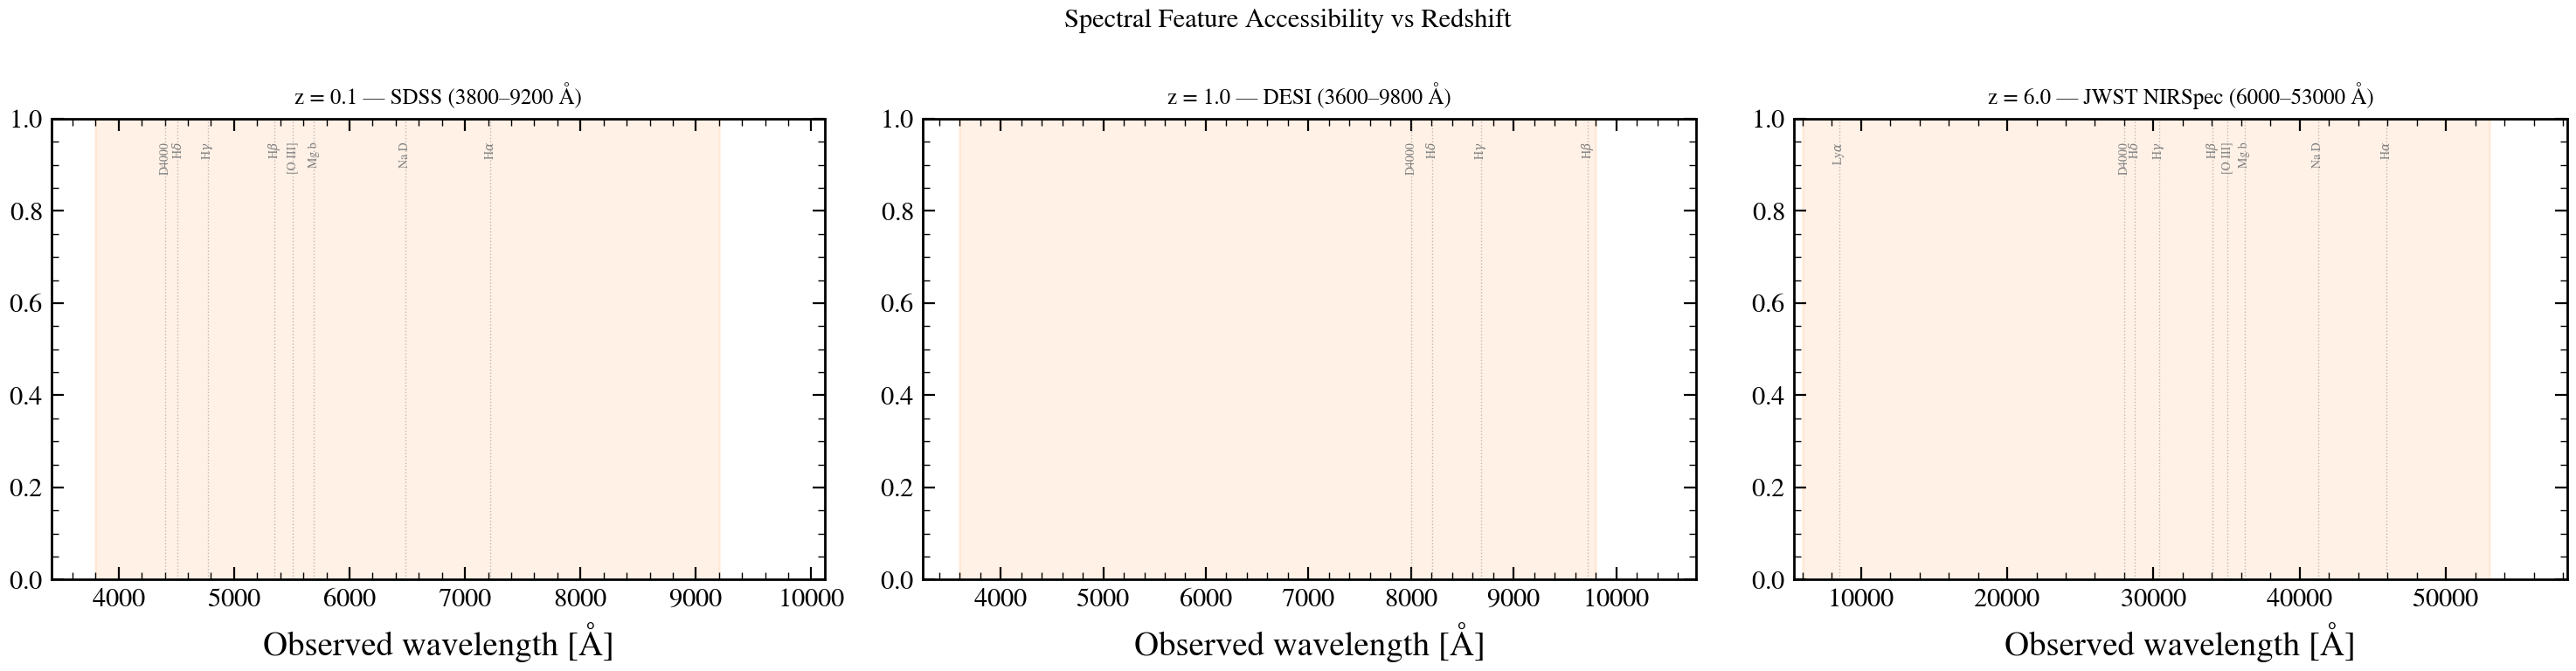

In [24]:
# --- FIGURE 10: Rest-frame features at z = 0.1, 1.0, 6.0 ---
redshifts = [0.1, 1.0, 6.0]
surveys = ["SDSS (3800–9200 Å)", "DESI (3600–9800 Å)", "JWST NIRSpec (6000–53000 Å)"]
windows = [(3800, 9200), (3600, 9800), (6000, 53000)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, z, survey, (wlo, whi) in zip(axes, redshifts, surveys, windows):
    # Mark features in rest-frame
    for feat_name, feat_wave in SPECTRAL_FEATURES.items():
        w_obs = feat_wave * (1 + z)
        if wlo < w_obs < whi:
            ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
            ax.text(
                w_obs,
                0.95,
                feat_name,
                fontsize=5,
                ha="center",
                va="top",
                rotation=90,
                transform=ax.get_xaxis_transform(),
                color="grey",
            )

    ax.axvspan(wlo, whi, alpha=0.1, color=COLORS["geovi"])
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_title(f"z = {z} — {survey}", fontsize=9)
    ax.set_xlim(wlo * 0.9, whi * 1.1)

fig.suptitle("Spectral Feature Accessibility vs Redshift", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig10_redshift_accessibility.png"), dpi=150, bbox_inches="tight")
plt.show()

## Practical Checklist

1. **Always run MAP first** — gives a sensible starting point.
2. **Check residuals** — reduced χ² ≈ 1, no systematic patterns.
3. **Mask bad pixels** — telluric absorption, sky lines, detector artifacts.
4. **Match resolution** — convolve templates to data resolution if needed.
5. **Wavelength-dependent noise** — use per-pixel uncertainties, not global SNR.
6. **Emission lines** — consider line marginalization for strong emitters.
7. **Convergence diagnostics** — ESS > 100, no divergences.